# Weekly FPL analysis

Thin notebook: all logic lives in `src/fpl`. This just calls the pipeline and inspects results.

In [5]:
from fpl import db

db.init_db()

## 1. Update data (scrape + references + stats)

Equivalent to running `python scripts/update_data.py`.

In [6]:
from fpl.scrape import understat
from fpl.reference import refresh as refresh_references
from fpl.stats import player_stats, team_gsxg

understat.run()
refresh_references.run()
player_stats.run()
team_gsxg.run()

No new Understat data for EPL 2026/2027
Teams: 20
Current FPL players matched to Understat history: 486
Players without a match: 58 (see C:\Users\colin\OneDrive\Documents\Data_Analysis\FPL\fpl-2627\data\unmatched_understat_names.csv)
Recalculated stats for 544 players
Recalculated GSxG factors for 20 teams


In [7]:
gsxg = db.read_table("gsxg")
gsxg_avg = db.read_table("gsxg_avg")
player_stats = db.read_table("understat_player_stats")

gsxg['team'].unique()

<StringArray>
[          'Arsenal',       'Aston Villa',       'Bournemouth',
         'Brentford',          'Brighton',           'Chelsea',
    'Crystal Palace',           'Everton',            'Fulham',
             'Leeds',         'Liverpool',   'Manchester City',
 'Manchester United',  'Newcastle United', 'Nottingham Forest',
        'Sunderland',         'Tottenham',          'Coventry',
              'Hull',           'Ipswich']
Length: 20, dtype: str

In [8]:
gsxg[gsxg['team'] == 'Manchester City']

,team,h_a,gamestate,xg_factor,xgc_factor
66,Manchester City,h,Winning,1.040927,0.690665
67,Manchester City,h,Draw,1.826854,0.769486
68,Manchester City,h,Losing,1.056950,1.049029
69,Manchester City,a,Winning,1.294081,0.784614
70,Manchester City,a,Draw,1.378418,1.003957
71,Manchester City,a,Losing,0.953005,0.623419


In [9]:
gsxg_team_avg = gsxg[['team', 'xg_factor', 'xgc_factor']].groupby('team').mean()
gsxg_team_avg.sort_values(by='xg_factor', ascending=False)

,xg_factor,xgc_factor
team,,
Manchester City,1.258372,0.820195
Arsenal,1.168218,0.739715
Chelsea,1.126513,0.997668
Liverpool,1.121070,0.999536
Manchester United,1.109244,0.875475
Brentford,1.089779,0.979499
Brighton,1.024502,0.811707
Crystal Palace,1.002217,0.997405
Nottingham Forest,0.995870,0.971080


In [10]:
gsxg_team_avg.sort_values(by='xgc_factor', ascending=True)

,xg_factor,xgc_factor
team,,
Arsenal,1.168218,0.739715
Brighton,1.024502,0.811707
Manchester City,1.258372,0.820195
Manchester United,1.109244,0.875475
Leeds,0.937931,0.883183
Sunderland,0.837655,0.925450
Tottenham,0.818641,0.941345
Nottingham Forest,0.995870,0.971080
Brentford,1.089779,0.979499


In [11]:
gsxg_avg

,h_a,gamestate,avg_xg_min,avg_xgc_min
0,a,Draw,0.018271,0.017803
1,a,Losing,0.013886,0.019435
2,a,Winning,0.019662,0.014125
3,h,Draw,0.019835,0.019561
4,h,Losing,0.014906,0.024873
5,h,Winning,0.025002,0.015487


## 2. Simulate upcoming gameweeks

In [23]:
from fpl.simulate import engine

N_SIMULATIONS = 10_000  # increase for more stable estimates, at the cost of runtime
N_GAMEWEEKS = 5

results = engine.simulate_next_gameweeks(n_simulations=N_SIMULATIONS, n_gameweeks=N_GAMEWEEKS)
gameweek_ids = sorted(results)
gameweek_ids


Simulating Gameweek 3
Simulating Ipswich Town vs. Liverpool
Simulating Newcastle vs. Bournemouth
Simulating Brentford vs. Sunderland
Simulating Brighton vs. Leeds
Simulating Fulham vs. Crystal Palace
Simulating Man City vs. Coventry City
Simulating Nott'm Forest vs. Spurs
Simulating Hull City vs. Aston Villa
Simulating Everton vs. Man Utd
Simulating Arsenal vs. Chelsea

Simulating Gameweek 4
Simulating Liverpool vs. Fulham
Simulating Crystal Palace vs. Ipswich Town
Simulating Bournemouth vs. Brentford
Simulating Aston Villa vs. Nott'm Forest
Simulating Chelsea vs. Hull City
Simulating Spurs vs. Everton
Simulating Sunderland vs. Arsenal
Simulating Coventry City vs. Brighton
Simulating Man Utd vs. Man City
Simulating Leeds vs. Newcastle

Simulating Gameweek 5
Simulating Brentford vs. Chelsea
Simulating Spurs vs. Aston Villa
Simulating Newcastle vs. Hull City
Simulating Leeds vs. Crystal Palace
Simulating Brighton vs. Arsenal
Simulating Everton vs. Ipswich Town
Simulating Nott'm Forest v

[np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]

### Sense-check: top predicted scorers per gameweek

In [24]:
gw_stats, scorelines = results[gameweek_ids[0]]
gw_stats.sort_values("points", ascending=False).head(15)

,minutes,goals,assists,clean_sheet,saves,goals_conceded,yellow_cards,red_cards,points
player,,,,,,,,,
Rayan Cherki,65.8834,0.4078,0.6390,0.2906,0.0,0.6390,0.0896,0.0,5.6581
Nico O'Reilly,67.9322,0.3315,0.1724,0.3262,0.0,0.6658,0.0865,0.0,5.1046
Erling Haaland,70.2459,0.8150,0.0859,0.3474,0.0,0.6786,0.0808,0.0,5.0598
Maxim De Cuyper,57.4351,0.3284,0.3943,0.1716,0.0,0.7548,0.0000,0.0,4.9495
Jack Hinshelwood,61.0639,0.5236,0.1496,0.2023,0.0,0.7949,0.0000,0.0,4.7021
Semi Ajayi,71.3601,0.4375,0.0000,0.1776,0.0,1.1380,0.0000,0.0,4.5789
Dango Ouattara,67.4203,0.3209,0.4141,0.1628,0.0,1.0802,0.0811,0.0,4.4640
Phil Foden,61.0234,0.2548,0.5232,0.2513,0.0,0.5890,0.1081,0.0,4.3935
Bruno Borges Fernandes,66.5932,0.1867,0.5988,0.2019,0.0,0.9586,0.1247,0.0,4.3476


In [25]:
for gw_id in gameweek_ids:
    print(f"\nGameweek {gw_id}")
    display(results[gw_id][0].sort_values("points", ascending=False).head(10))


Gameweek 3


,minutes,goals,assists,clean_sheet,saves,goals_conceded,yellow_cards,red_cards,points
player,,,,,,,,,
Rayan Cherki,65.8834,0.4078,0.6390,0.2906,0.0,0.6390,0.0896,0.0,5.6581
Nico O'Reilly,67.9322,0.3315,0.1724,0.3262,0.0,0.6658,0.0865,0.0,5.1046
Erling Haaland,70.2459,0.8150,0.0859,0.3474,0.0,0.6786,0.0808,0.0,5.0598
Maxim De Cuyper,57.4351,0.3284,0.3943,0.1716,0.0,0.7548,0.0000,0.0,4.9495
Jack Hinshelwood,61.0639,0.5236,0.1496,0.2023,0.0,0.7949,0.0000,0.0,4.7021
Semi Ajayi,71.3601,0.4375,0.0000,0.1776,0.0,1.1380,0.0000,0.0,4.5789
Dango Ouattara,67.4203,0.3209,0.4141,0.1628,0.0,1.0802,0.0811,0.0,4.4640
Phil Foden,61.0234,0.2548,0.5232,0.2513,0.0,0.5890,0.1081,0.0,4.3935
Bruno Borges Fernandes,66.5932,0.1867,0.5988,0.2019,0.0,0.9586,0.1247,0.0,4.3476



Gameweek 4


,minutes,goals,assists,clean_sheet,saves,goals_conceded,yellow_cards,red_cards,points
player,,,,,,,,,
Morgan Gibbs-White,66.3908,0.6261,0.2220,0.2020,0.0,1.0558,0.0000,0.0,5.5046
Dominic Calvert-Lewin,66.7879,0.7433,0.0000,0.3464,0.0,0.5478,0.1875,0.0,4.3510
Maxim De Cuyper,56.9876,0.2407,0.3057,0.2091,0.0,0.7490,0.0000,0.0,4.2824
Bruno Borges Fernandes,66.9271,0.1767,0.5910,0.1505,0.0,1.0651,0.1287,0.0,4.2268
Daniel Muñoz Mejía,57.3590,0.2957,0.1686,0.2081,0.0,0.6299,0.1473,0.0,4.1235
Cole Palmer,62.4673,0.3495,0.2195,0.2605,0.0,0.6285,0.0674,0.0,4.0633
Jack Hinshelwood,60.9409,0.3951,0.1135,0.2486,0.0,0.8049,0.0000,0.0,3.9968
Dominik Szoboszlai,71.7885,0.1830,0.4397,0.2349,0.0,0.9126,0.1236,0.0,3.9939
Ollie Watkins,67.3290,0.6121,0.0791,0.0965,0.0,1.5922,0.2241,0.0,3.9835



Gameweek 5


,minutes,goals,assists,clean_sheet,saves,goals_conceded,yellow_cards,red_cards,points
player,,,,,,,,,
Rayan Cherki,65.6684,0.3512,0.5504,0.2554,0.0,0.7049,0.0910,0.0,5.0696
Marcus Tavernier,74.9948,0.4903,0.2544,0.0565,0.0,1.9008,0.2464,0.0,4.7290
Nico O'Reilly,67.4703,0.3004,0.1535,0.2853,0.0,0.7317,0.0856,0.0,4.6775
Dango Ouattara,67.0812,0.3471,0.4382,0.1137,0.0,1.4875,0.0768,0.0,4.6112
Dominik Szoboszlai,72.1485,0.2346,0.5775,0.1293,0.0,1.5381,0.1294,0.0,4.5592
Erling Haaland,70.1052,0.6898,0.0758,0.3020,0.0,0.7578,0.0731,0.0,4.5316
Cody Gakpo,70.8137,0.3609,0.2975,0.1213,0.0,1.5248,0.0682,0.0,4.3793
Bruno Borges Fernandes,67.2743,0.1788,0.6218,0.1585,0.0,1.1598,0.1204,0.0,4.3525
Morgan Gibbs-White,66.1230,0.4371,0.1535,0.2042,0.0,1.0061,0.0000,0.0,4.3503



Gameweek 6


,minutes,goals,assists,clean_sheet,saves,goals_conceded,yellow_cards,red_cards,points
player,,,,,,,,,
Jack Rudoni,57.0618,0.5923,0.1911,0.1879,0.0,0.6194,0.0000,0.0,5.0556
Semi Ajayi,71.0808,0.5222,0.0001,0.1635,0.0,1.1524,0.0000,0.0,5.0224
Loum Tchaouna,59.9524,0.3516,0.5169,0.2182,0.0,0.6608,0.0931,0.0,4.8474
Bruno Borges Fernandes,67.3611,0.2117,0.6732,0.2236,0.0,0.7445,0.1269,0.0,4.7293
Taiwo Awoniyi,46.5621,0.8452,0.0962,0.1316,0.0,0.4814,0.1815,0.0,4.6119
Morgan Gibbs-White,66.4987,0.4739,0.1637,0.1827,0.0,1.0857,0.0000,0.0,4.5524
Saša Lukić,70.8014,0.2326,0.5316,0.1758,0.0,1.0811,0.2852,0.0,4.2787
Rayan Cherki,65.9007,0.2762,0.4344,0.1406,0.0,0.9951,0.0865,0.0,4.2397
Bryan Mbeumo,62.4882,0.4652,0.1206,0.1920,0.0,0.6934,0.0787,0.0,4.2369



Gameweek 7


,minutes,goals,assists,clean_sheet,saves,goals_conceded,yellow_cards,red_cards,points
player,,,,,,,,,
Rayan Cherki,66.1055,0.4336,0.6579,0.2993,0.0,0.6000,0.0930,0.0,5.8520
Maxim De Cuyper,57.1248,0.4127,0.4839,0.1618,0.0,0.7944,0.0000,0.0,5.6654
Nico O'Reilly,67.5395,0.3614,0.1824,0.3291,0.0,0.6270,0.0862,0.0,5.3386
Jack Hinshelwood,60.7279,0.6295,0.1748,0.1997,0.0,0.8574,0.0000,0.0,5.3021
Erling Haaland,70.3800,0.8266,0.0910,0.3494,0.0,0.6520,0.0752,0.0,5.1250
Dango Ouattara,67.5902,0.3524,0.4496,0.0708,0.0,1.5978,0.0783,0.0,4.6374
Diego Gómez Amarilla,64.5879,0.4476,0.3258,0.1987,0.0,0.9171,0.2931,0.0,4.5883
Phil Foden,61.1252,0.2733,0.5515,0.2588,0.0,0.5626,0.1101,0.0,4.5725
Marc Guéhi,71.7100,0.2060,0.1244,0.3630,0.0,0.6697,0.0715,0.0,4.4505


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def scoreline_heatmap(scorelines, home_team, away_team, max_goals=5):
    """Heatmap of P(home_goals, away_goals) for one fixture.

    scorelines: the dict returned alongside gw_stats from simulate_next_gameweeks,
    keyed by (home_team, away_team) -> {(home_goals, away_goals): probability}.
    Scores above max_goals are bucketed into a "N+" row/column so the
    displayed probabilities still sum to (close to) 100%.
    """
    probs = scorelines[(home_team, away_team)]

    df = pd.Series(probs).rename_axis(["home_goals", "away_goals"]).reset_index(name="prob")
    df["home_goals"] = df["home_goals"].clip(upper=max_goals)
    df["away_goals"] = df["away_goals"].clip(upper=max_goals)
    grid = df.groupby(["home_goals", "away_goals"])["prob"].sum().unstack(fill_value=0)
    grid = grid.reindex(index=range(max_goals + 1), columns=range(max_goals + 1), fill_value=0)

    labels = [str(i) for i in range(max_goals)] + [f"{max_goals}+"]
    grid.index = labels
    grid.columns = labels

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(grid, annot=True, fmt=".1%", cmap="viridis",
                cbar_kws={"label": "Probability"}, ax=ax)
    ax.set_xlabel(f"{away_team} goals")
    ax.set_ylabel(f"{home_team} goals")
    ax.set_title(f"{home_team} vs {away_team} — scoreline probabilities\n"
                 f"(covers {df['prob'].sum():.1%} of simulated outcomes)")
    ax.invert_yaxis()  # 0 goals at the bottom, like a normal grid
    
    # Calculate result probabilities
    home_win_prob = sum(prob for (h, a), prob in probs.items() if h > a)
    draw_prob = sum(prob for (h, a), prob in probs.items() if h == a)
    away_win_prob = sum(prob for (h, a), prob in probs.items() if h < a)
    
    probabilities = {
        "home_win": home_win_prob,
        "draw": draw_prob,
        "away_win": away_win_prob
    }
    
    return ax, probabilities

In [26]:
gw_stats, scorelines = results[gameweek_ids[1]]

# check the exact team-name strings used as keys before calling the function
list(scorelines.keys())

[('Liverpool', 'Fulham'),
 ('Crystal Palace', 'Ipswich Town'),
 ('Bournemouth', 'Brentford'),
 ('Aston Villa', "Nott'm Forest"),
 ('Chelsea', 'Hull City'),
 ('Spurs', 'Everton'),
 ('Sunderland', 'Arsenal'),
 ('Coventry City', 'Brighton'),
 ('Man Utd', 'Man City'),
 ('Leeds', 'Newcastle')]

{'home_win': 0.4478, 'draw': 0.1292, 'away_win': 0.423}

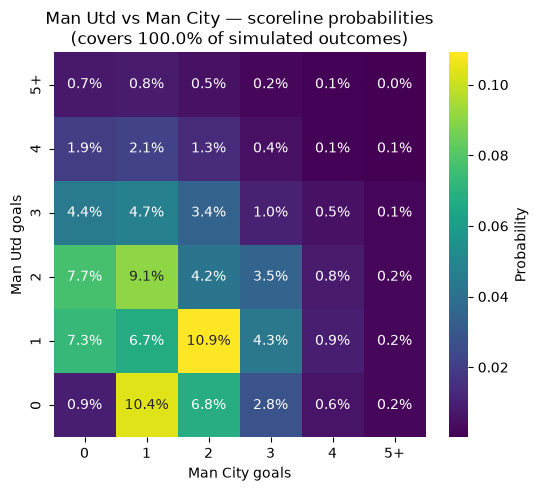

In [27]:
# Cell — plot one fixture
home_team = 'Man Utd'
away_team = 'Man City'

ax, probabilities = scoreline_heatmap(scorelines, home_team, away_team, max_goals=5)

probabilities

## 3. Optimise squad

`fpl.squad.optimize` builds each player's expected points as a weighted
average across `N_GAMEWEEKS` (nearer gameweeks weighted more heavily —
see `optimize.GAMEWEEK_WEIGHTS`), then solves for the best squad under
FPL's budget/position/club constraints via `fpl.squad.optimize.select_squad`.

This picks a squad from scratch. If you're planning transfers for a squad
you already own, skip to section 4 instead.

In [28]:
from fpl.squad import optimize

# optimize.GAMEWEEK_WEIGHTS defaults to [10, 9, 8, 7, 6] (len must match
# N_GAMEWEEKS above); trim/extend it if you changed N_GAMEWEEKS.
weights = optimize.GAMEWEEK_WEIGHTS[:N_GAMEWEEKS]

player_pool = optimize.build_player_pool(results, gameweek_ids=gameweek_ids, weights=weights)
player_pool.sort_values("expected_points", ascending=False).head(10)

,fpl_id,position,team,now_cost,expected_points
player,,,,,
Rayan Cherki,399,MID,Man City,7.6,4.866877
Maxim De Cuyper,115,DEF,Brighton,4.6,4.508340
Erling Haaland,411,FWD,Man City,15.5,4.396478
Morgan Gibbs-White,480,MID,Nott'm Forest,7.9,4.363305
Nico O'Reilly,387,DEF,Man City,6.5,4.319567
Bruno Borges Fernandes,426,MID,Man Utd,12.0,4.304542
Jack Hinshelwood,123,MID,Brighton,6.0,4.295187
Dominik Szoboszlai,368,MID,Liverpool,7.0,4.161518
Dango Ouattara,95,MID,Brentford,6.5,4.122113


### Best squad from scratch

In [29]:
squad = optimize.select_squad(player_pool, expected_points_col="expected_points")

print(f"Total cost: {squad['now_cost'].sum():.1f}")
print(f"Total weighted expected points: {squad['expected_points'].sum():.2f}")
display(squad.sort_values(["position", "expected_points"], ascending=[True, False]))

Total cost: 99.9
Total weighted expected points: 58.85


,fpl_id,position,team,now_cost,expected_points
player,,,,,
Maxim De Cuyper,115,DEF,Brighton,4.6,4.508340
Nico O'Reilly,387,DEF,Man City,6.5,4.319567
Semi Ajayi,279,DEF,Hull City,4.0,3.907425
Ferdi Kadıoğlu,113,DEF,Brighton,4.4,3.377705
Timothy Castagne,258,DEF,Fulham,4.5,3.192477
Erling Haaland,411,FWD,Man City,15.5,4.396478
Ollie Watkins,55,FWD,Aston Villa,7.9,3.958980
Igor Thiago Nascimento Rodrigues,106,FWD,Brentford,8.0,3.819998
Caoimhín Kelleher,82,GKP,Brentford,5.0,2.881295


### Best starting XI + captain per gameweek

`evaluate_squad` needs one points column per gameweek (not the single
blended `expected_points` column above), so pull those straight out of
`results` for just the squad we picked.

In [30]:
from fpl.squad.evaluate import evaluate_squad

points_columns = [f"GW {gw_id} points" for gw_id in gameweek_ids]
squad_gw_points = squad.copy()
for gw_id, col in zip(gameweek_ids, points_columns):
    squad_gw_points[col] = results[gw_id][0].reindex(squad.index)["points"].fillna(0.0)

total_weighted_points, lineups = evaluate_squad(squad_gw_points, points_columns, weights)

print(f"Total weighted points across {len(gameweek_ids)} gameweeks: {total_weighted_points:.2f}")
for week_number, gw_id in enumerate(gameweek_ids, start=1):
    lineup = lineups[week_number]
    print(f"\nGameweek {gw_id} — {lineup['gw_points']:.2f} pts, captain: {lineup['captain']}")
    print(", ".join(lineup["lineup"]))

Total weighted points across 5 gameweeks: 2073.59

Gameweek 3 — 55.27 pts, captain: Rayan Cherki
Caoimhín Kelleher, Nico O'Reilly, Maxim De Cuyper, Semi Ajayi, Rayan Cherki, Jack Hinshelwood, Dango Ouattara, Morgan Gibbs-White, Erling Haaland, Igor Thiago Nascimento Rodrigues, Ollie Watkins

Gameweek 4 — 47.61 pts, captain: Morgan Gibbs-White
Caoimhín Kelleher, Maxim De Cuyper, Ferdi Kadıoğlu, Semi Ajayi, Morgan Gibbs-White, Jack Hinshelwood, Marcus Tavernier, Rayan Cherki, Dango Ouattara, Ollie Watkins, Erling Haaland

Gameweek 5 — 51.31 pts, captain: Rayan Cherki
Jordan Pickford, Nico O'Reilly, Maxim De Cuyper, Timothy Castagne, Rayan Cherki, Marcus Tavernier, Dango Ouattara, Morgan Gibbs-White, Erling Haaland, Igor Thiago Nascimento Rodrigues, Ollie Watkins

Gameweek 6 — 49.07 pts, captain: Semi Ajayi
Caoimhín Kelleher, Semi Ajayi, Maxim De Cuyper, Ferdi Kadıoğlu, Nico O'Reilly, Morgan Gibbs-White, Rayan Cherki, Jack Hinshelwood, Marcus Tavernier, Ollie Watkins, Erling Haaland

Game

## 4. Plan transfers for your existing squad

Fetches your current squad and finds the best one reachable within
`MAX_TRANSFERS` changes, using `fpl.squad.optimize.plan_transfers`. This
models real transfer economics — keeping a player costs nothing, each
outgoing player refunds its sale price, each incoming player costs its
market price, and total spend can't exceed bank + refunds.

If `FPL_EMAIL`/`FPL_PASSWORD` are set in `.env`, this authenticates via
`fpl.squad.my_team` to get your *real* sale prices and bank balance
(FPL's sell-on fee means sale price can trail market price). Otherwise
it falls back to the public picks endpoint, approximates sale price
from current market price, and treats bank as £0. Skip this section if
you'd rather just look at the from-scratch squad above.

In [31]:
from fpl.squad import my_team

try:
    picks_df, transfer_status = my_team.fetch_my_team()
    id_to_name = {row.fpl_id: name for name, row in player_pool.iterrows()}
    current_squad = [id_to_name[fpl_id] for fpl_id in picks_df.index]
    bank = transfer_status["bank"]

    # Attach real sale prices to player_pool (only meaningful for
    # current-squad players -- everyone else keeps their market price).
    player_pool["selling_price"] = player_pool["now_cost"]
    fpl_id_to_selling_price = picks_df["selling_price"].to_dict()
    for name in current_squad:
        player_pool.loc[name, "selling_price"] = fpl_id_to_selling_price[player_pool.loc[name, "fpl_id"]]

    print(
        f"Authenticated via FPL_EMAIL/FPL_PASSWORD — bank £{bank:.1f}m, "
        f"{transfer_status['free_transfers']} free transfer(s), "
        f"squad sale value £{player_pool.loc[current_squad, 'selling_price'].sum():.1f}m "
        "(real sell-on prices, not market prices)."
    )
except ValueError:
    # FPL_EMAIL/FPL_PASSWORD not set in .env -- fall back to the public
    # picks endpoint. Sale price is then approximated as current market
    # price, which can overstate it slightly for any player who's risen
    # in value since you bought them.
    import requests

    from fpl.config import FPL_ENTRY_ID, FPL_ENTRY_URL_TEMPLATE, FPL_PICKS_URL_TEMPLATE

    if not FPL_ENTRY_ID:
        raise ValueError("Set FPL_ENTRY_ID in .env to fetch your current squad (see .env.example)")

    entry = requests.get(FPL_ENTRY_URL_TEMPLATE.format(entry_id=FPL_ENTRY_ID), timeout=30).json()
    current_event = entry["current_event"]
    picks_url = FPL_PICKS_URL_TEMPLATE.format(entry_id=FPL_ENTRY_ID, event_id=current_event)
    picks = requests.get(picks_url, timeout=30).json()["picks"]

    id_to_name = {row.fpl_id: name for name, row in player_pool.iterrows()}
    current_squad = [id_to_name[pick["element"]] for pick in picks]
    bank = 0.0  # unknown without authenticating -- treat as 0 rather than guess
    player_pool["selling_price"] = player_pool["now_cost"]  # approximation, see caveat above
    print(
        "No FPL_EMAIL/FPL_PASSWORD in .env — approximating sale price from current market price "
        "and treating bank as £0.0m. Set them to use fpl.squad.my_team for exact figures."
    )

current_squad

Authenticated via FPL_EMAIL/FPL_PASSWORD — bank £0.0m, 2 free transfer(s), squad sale value £100.0m (real sell-on prices, not market prices).


['Antonín Kinský',
 "Nico O'Reilly",
 'Pedro Porro Sauceda',
 'Adrien Truffert',
 'Marcus Tavernier',
 'Jack Hinshelwood',
 'Bryan Mbeumo',
 'Bruno Borges Fernandes',
 'Pascal Groß',
 'Erling Haaland',
 'Dominic Calvert-Lewin',
 'Bart Verbruggen',
 'Riccardo Calafiori',
 'Jonah Kusi-Asare',
 'Ola Aina']

In [32]:
MAX_TRANSFERS = 2  # None for unlimited; free hits aside, more transfers cost 4pts each in FPL

new_squad = optimize.plan_transfers(
    player_pool,
    current_squad=current_squad,
    expected_points_col="expected_points",
    bank=bank,
    sale_price_col="selling_price",
    max_transfers=MAX_TRANSFERS,
)

players_out = [name for name in current_squad if name not in new_squad.index]
players_in = [name for name in new_squad.index if name not in current_squad]

if not players_out:
    print("No transfer recommended — current squad is already the best affordable option.")
else:
    for out_name, in_name in zip(players_out, players_in):
        print(f"OUT: {out_name}  ->  IN: {in_name}")

old_points = player_pool.loc[current_squad, "expected_points"].sum()
print(f"\nOld total weighted expected points: {old_points:.2f}")
print(f"New total weighted expected points: {new_squad['expected_points'].sum():.2f}")

OUT: Pedro Porro Sauceda  ->  IN: Taiwo Awoniyi
OUT: Jonah Kusi-Asare  ->  IN: Semi Ajayi

Old total weighted expected points: 46.89
New total weighted expected points: 51.34
